In [1]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
import random

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl  
##############################################################

def read_state():
    state = aln.getZeroFullState()
    for v in range(len(state_vars)):
        state[0,v,:] = aln.state[state_vars[v]][0,:]
    return state

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
##############################################################

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

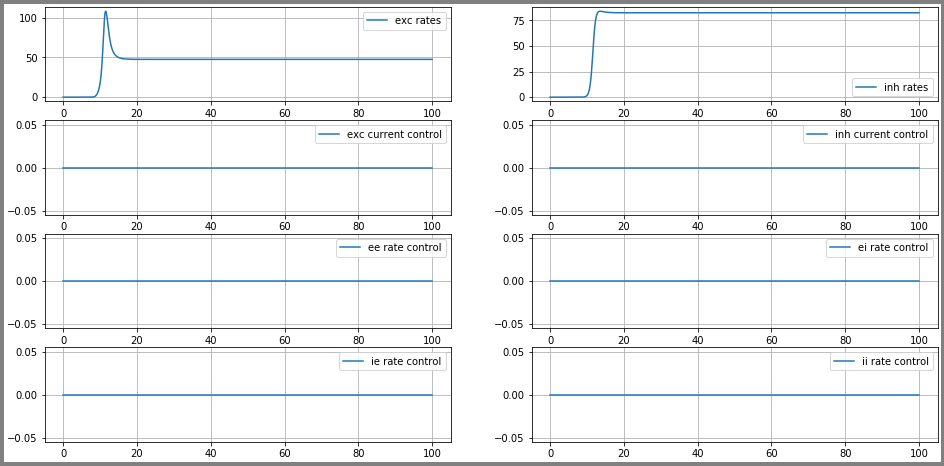

In [60]:
aln.params['duration'] = 100.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()

aln.params.ext_exc_current = 2.5
aln.params.ext_inh_current = 2.

aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5

# NO ADAPTATION
aln.params.a = 0.
aln.params.b = 0.

aln.params.de = 0.
aln.params.di = 0.
aln.params.SignalV = 0.

plotFunc.plot_traces(aln, control0)
initVars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        initVars[i] = aln.state[state_vars[i]][0] 
    else:
        initVars[i] = aln.state[state_vars[i]][0,-1]

in sigma :  0.0004147132217046515 12.486560136624425
1.6406887553349951 0.0 0.5045016479925047
tau exc =  9 1.0369990609702118
in sigma :  0.0004147132217046515 26.40288184116988
1.6406887553349951 0.0 0.5028591805400785
tau exc =  10 1.0369990609702118
seiv  0.0004147132217046515 0.00033346548942477335
z1ei  26.40288184116988 26.40288184116988


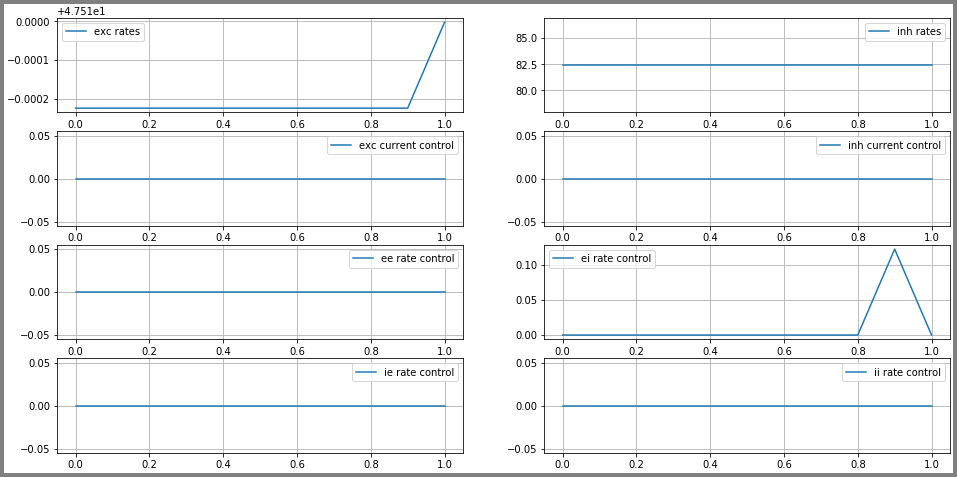

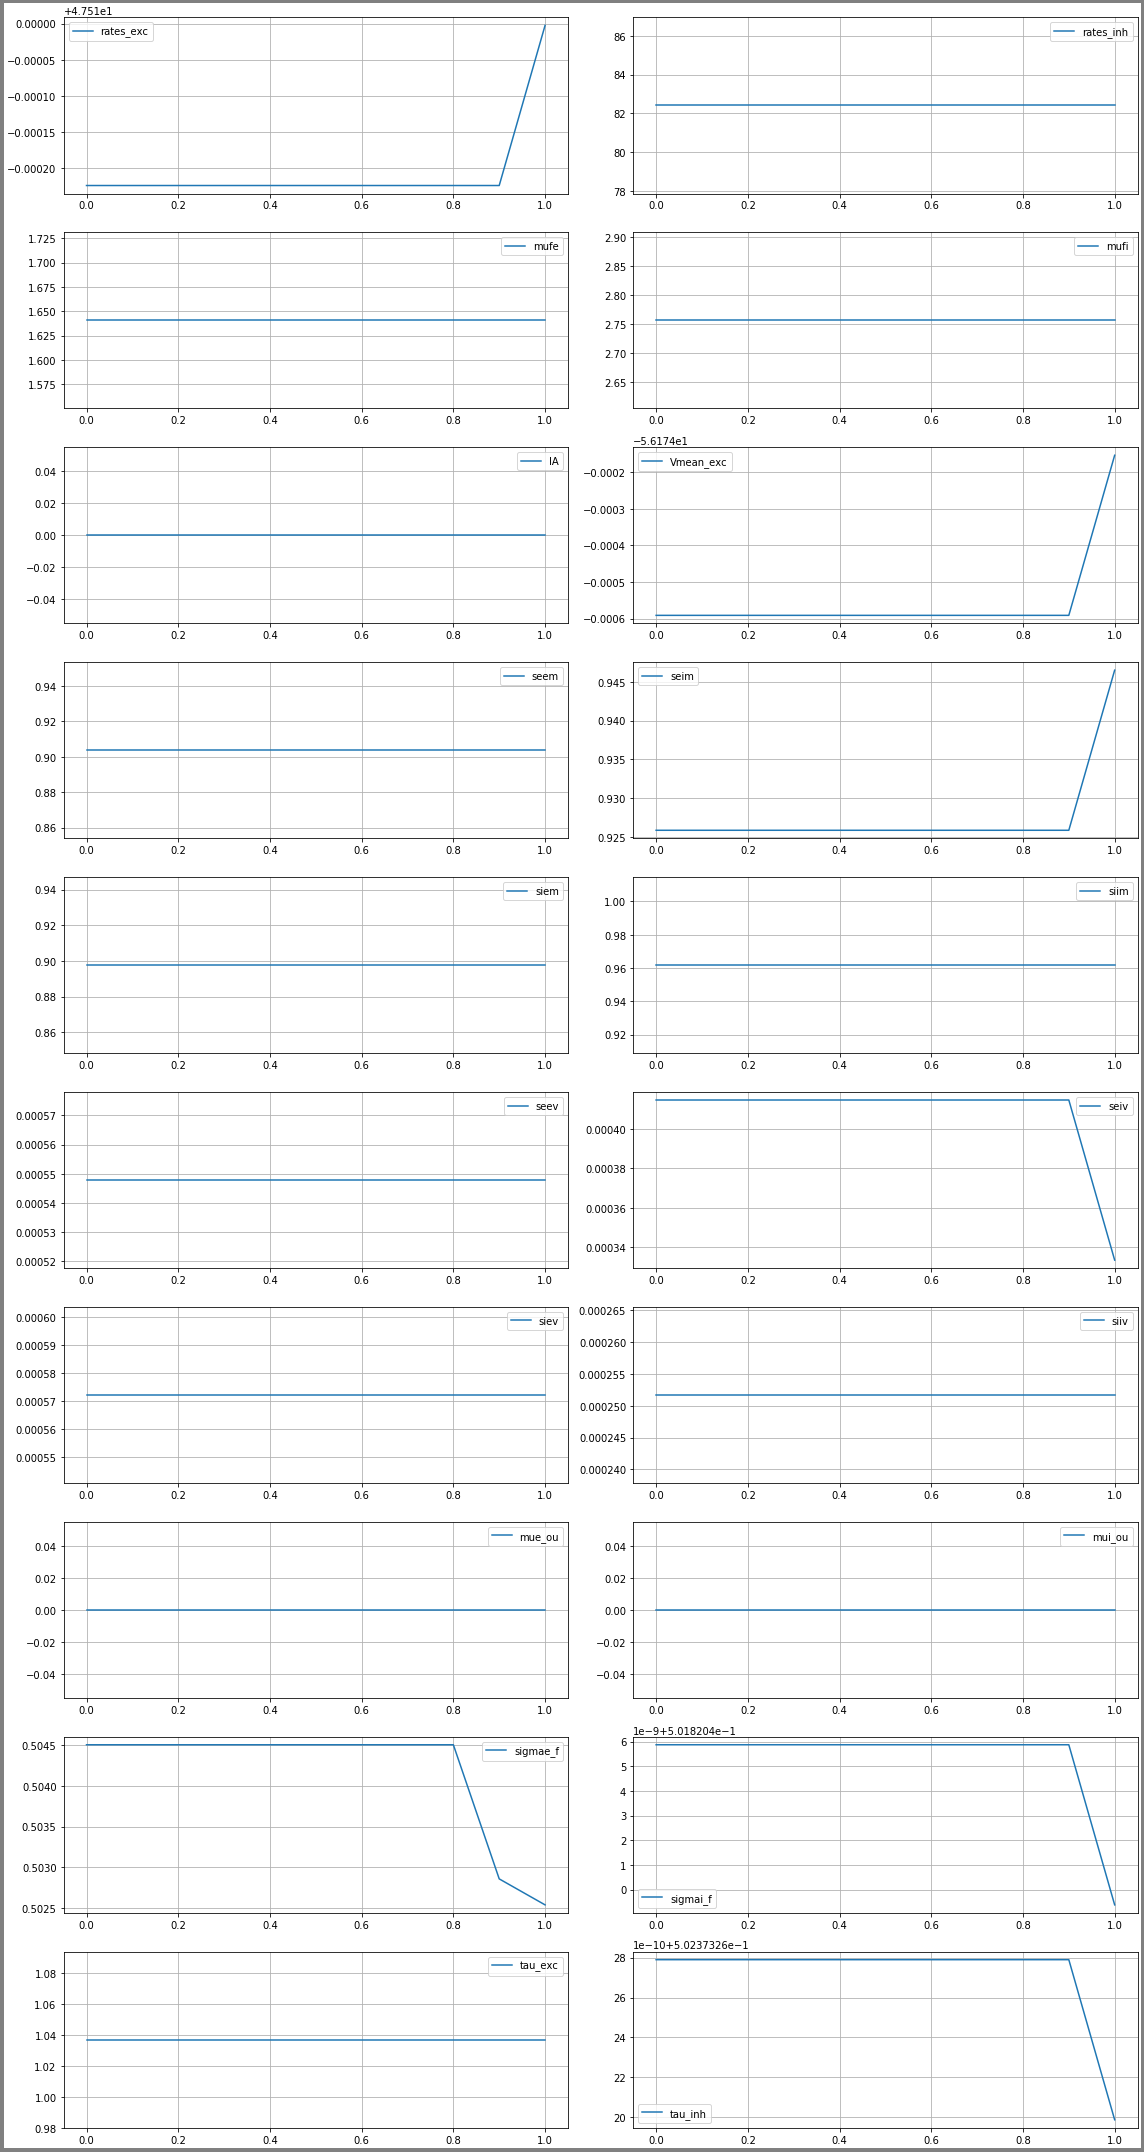

In [76]:
dur = 1.
dur_pre = 0.3
dur_post = 0.3
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

control0 = aln.getZeroControl()
setinit(initVars)

cntrl_vars = [3]

control0[0,cntrl_vars[0],9] = 0.122463631
plotFunc.plot_traces(aln, control0)

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = aln.rates_exc[0,:]
target[:,1,:] = aln.rates_inh[0,:]

fullState = read_state()
plotFunc.plot_fullState(fullState, dur, aln.params.dt, state_vars, path, filename_ = "full_state.png")

tau exc =  1 1.0369990609702118
tau exc =  2 1.0369990609702118
tau exc =  3 1.0369990609702118
tau exc =  4 1.0369990609702118
tau exc =  5 1.0369990609702118
tau exc =  6 1.0369990609702118
tau exc =  7 1.0369990609702118
tau exc =  8 1.0369990609702118
tau exc =  9 1.0369990609702118
tau exc =  10 1.0369990609702118
12.486560136624425 -113.63636363636364 0.0 0.122463632
seiv  0.0004147132217046515 0.0007951681012010828
z1ei  -1.4297616815573946 -1.4297616815573946


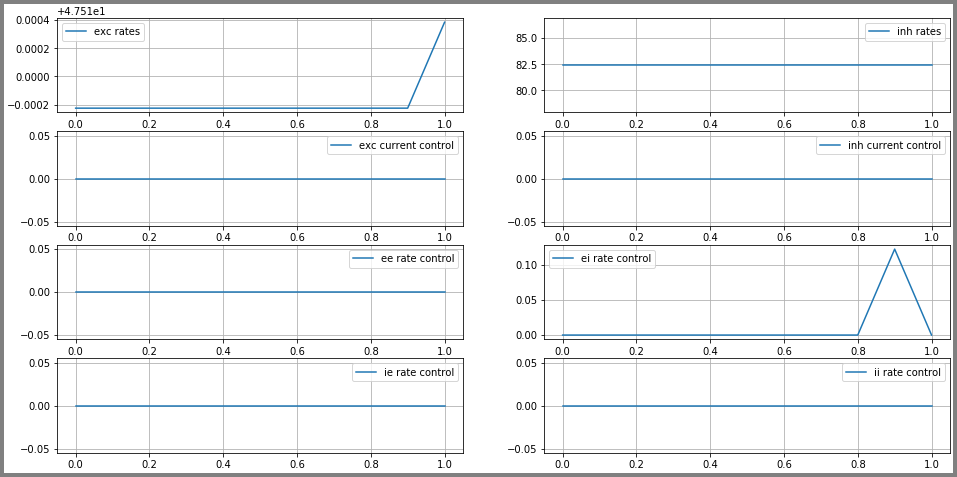

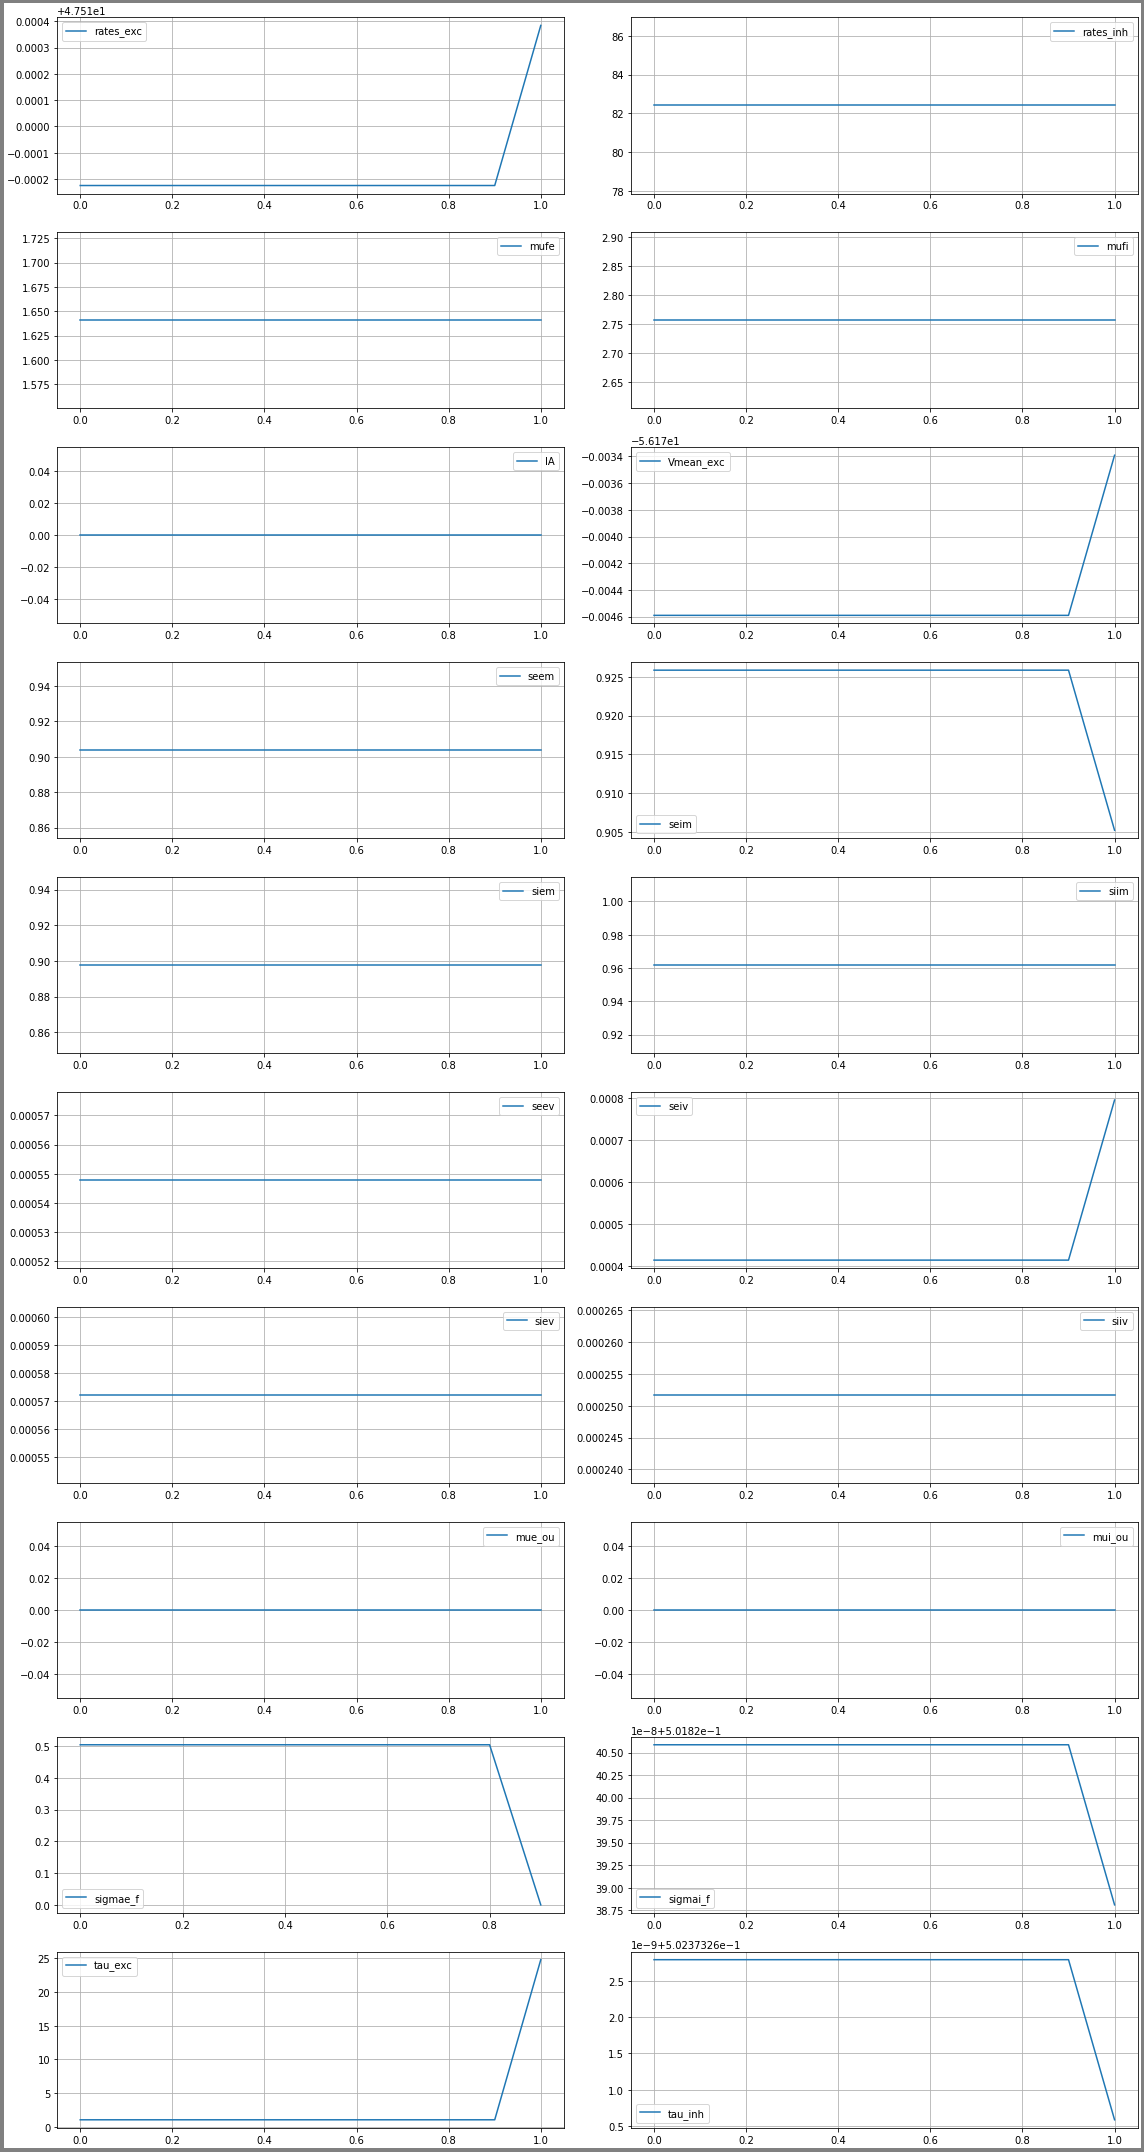

In [71]:
control0[0,cntrl_vars[0],9] = 0.122463632
plotFunc.plot_traces(aln, control0)

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = aln.rates_exc[0,:]
target[:,1,:] = aln.rates_inh[0,:]

fullState = read_state()
plotFunc.plot_fullState(fullState, dur, aln.params.dt, state_vars, path, filename_ = "full_state_1.png")

set cost params
interpolate adjoint :  True True True


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  0 , total integrated cost =  2.465637817216786e-09
Gradient descend method:  None
RUN  1 , total integrated cost =  1.8943234970801934e-10
RUN  1 , total integrated cost =  1.8943234970801934e-10
Improved over  1  iterations in  0.0067398000001048786  seconds by  92.31710560305038  percent.
Problem in initial value trasfer:  sigmae_f 0.5026930718784539 0.5038115551115872
Problem in initial value trasfer:  Vmean_exc -56.17419915169818 -56.17394488138829
[ 8.92355503e-04  9.23671554e-04  9.41187232e-04  9.37484782e-04
  9.01910664e-04  8.18984125e-04  6.65767429e-04  4.07380611e-04
 -1.56505975e-07 -8.09295316e-07  0.00000000e+00]


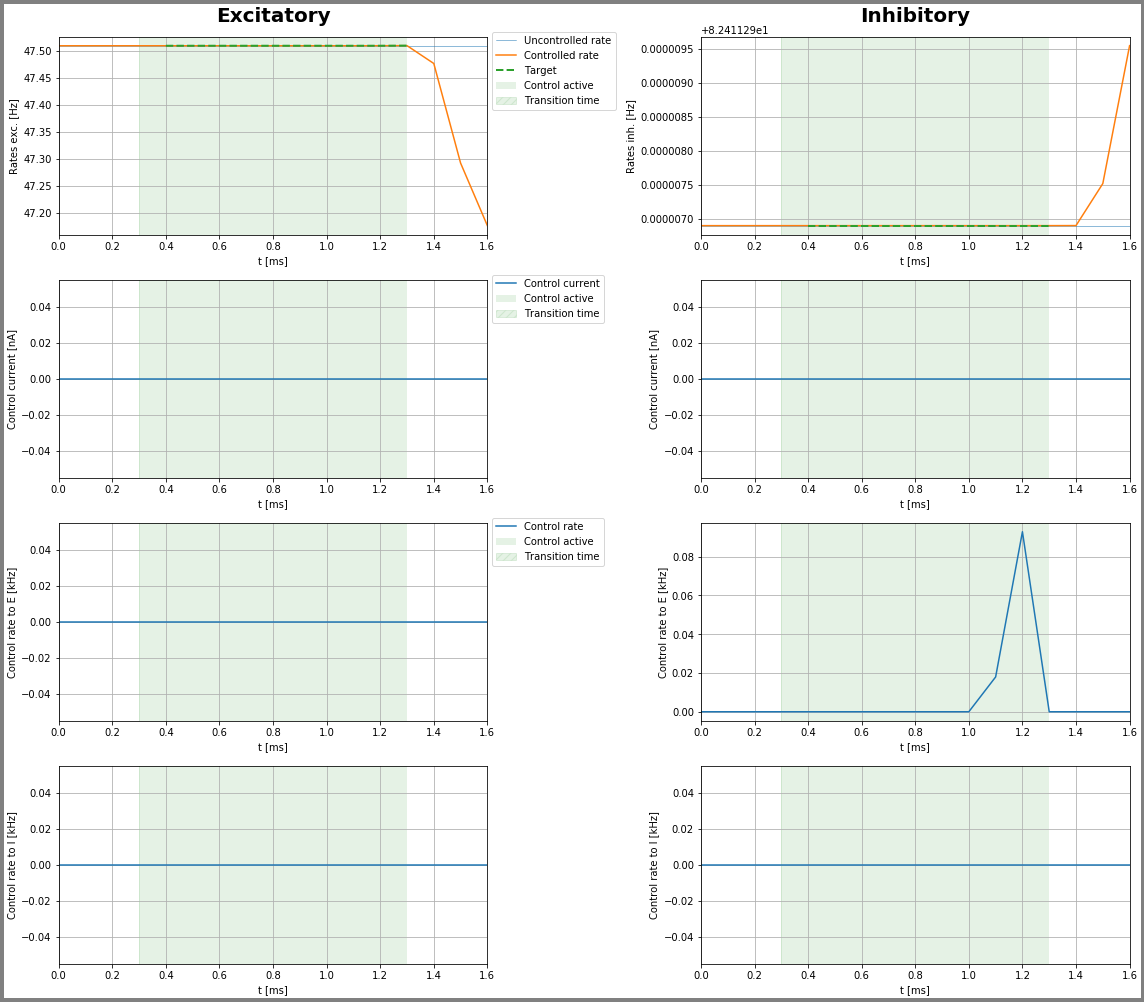

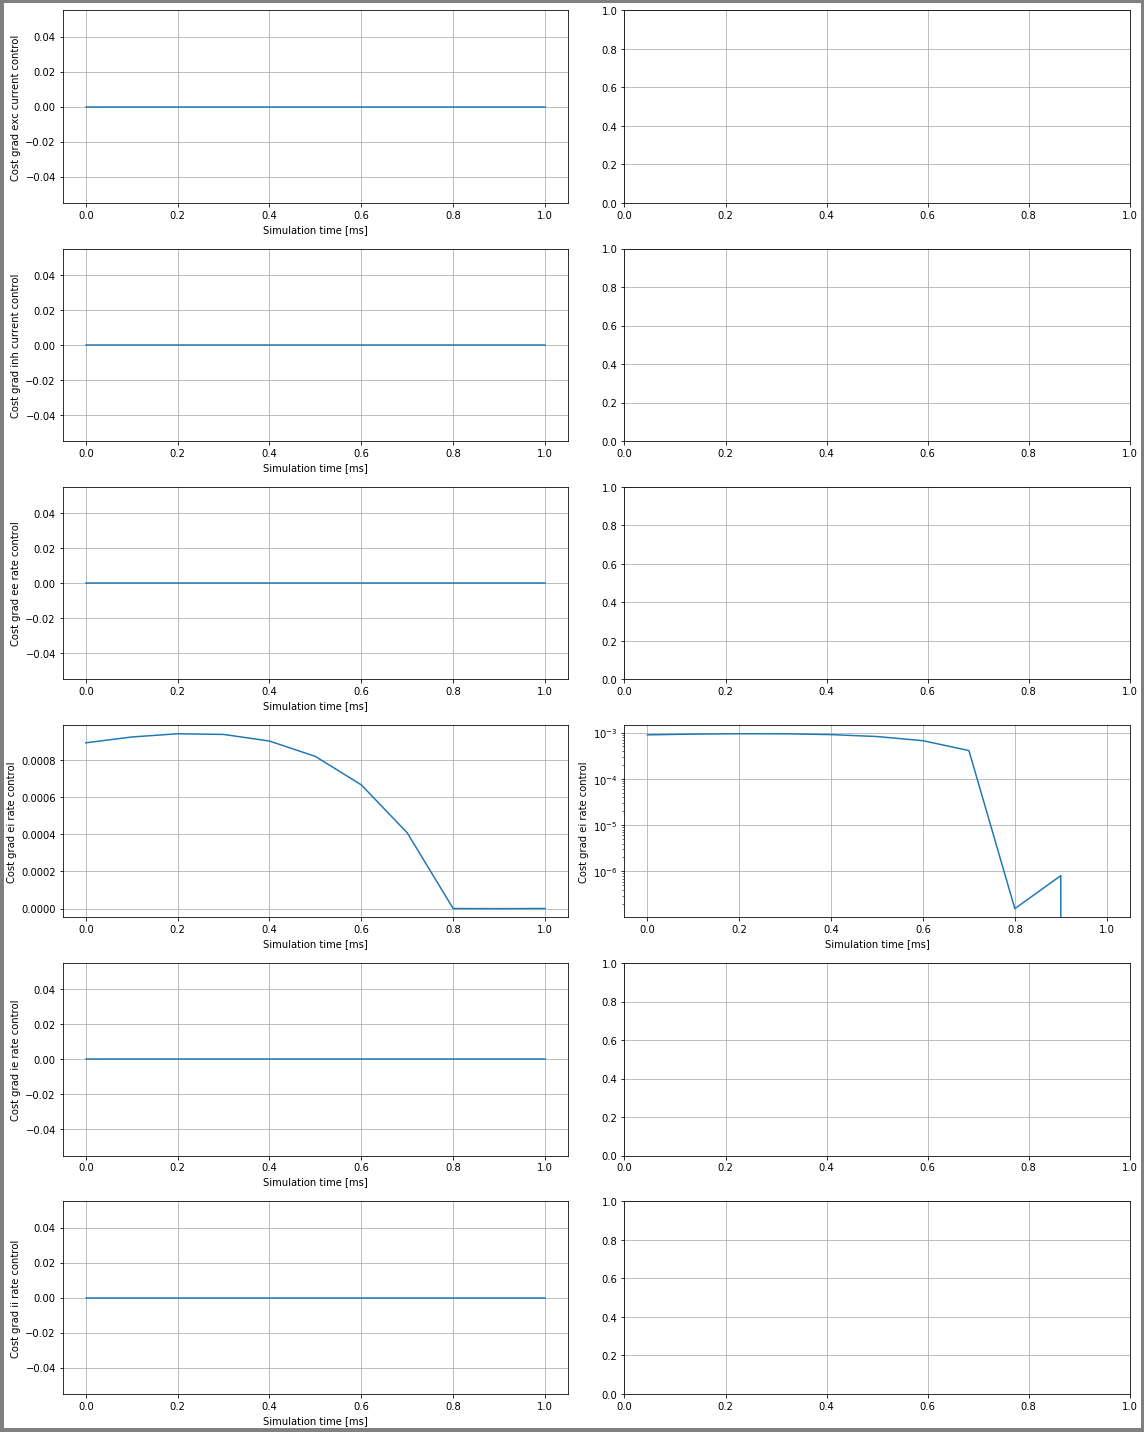

In [78]:
cost.setParams(1.0, 0.0, 0.0)
prec_vars = [0]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None
max_it = 1

bestControla, bestStatea, costa, runtimea, grada, phia = aln.A1(control0,
    target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = 0.)

print(grada[0,cntrl_vars[0],:])

plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = "test", transition_time_ = 0. )
plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
